# Inlet Separator Safety System — End-to-End Demo

This notebook drives the Java reference example
[`InletSeparatorSafetySystemExample.java`](../../src/main/java/neqsim/process/examples/InletSeparatorSafetySystemExample.java)
from Python and visualises the safety-engineering deliverables on top of it.

It demonstrates a complete safety package around an inlet three-phase separator:

| Tag | Device | Role |
|---|---|---|
| ESDV-1001 | Inlet emergency-shutdown valve (fail-closed) | Final element of the inlet ESD SIF |
| V-100 | Three-phase inlet separator (PD = 100 bara, MAWP = 110 bara) | Bulk gas/oil/water separation |
| PV-1001 / LV-1001 / LV-1002 | Outlet control valves | BPCS pressure & level control |
| PT/TT/LT-1001 / LT-1002 | Transmitters with LL/L/H/HH alarms | Process monitoring |
| PSV-1001 | Spring-loaded relief valve | Sized per **API 520** for blocked-outlet + external-fire |
| SIF-001 / SIF-002 / SIF-003 | Safety Instrumented Functions | **IEC 61511** SIL 2 / 1 / 2 |
| LOPA worksheet | Independent Protection Layers | Mitigated frequency ≤ STS-0131 target |

**Standards:** API 520/521, IEC 61508 / 61511, NORSOK S-001, ISA 84.00.01, CCPS LOPA, STS-0131.

**Setup:** uses `devtools/neqsim_dev_setup.py` so the workspace `target/classes`
is on the classpath — this picks up newly-added Java classes without needing
to package + install the JAR.

## 1. Devtools setup — start JVM on the workspace classpath

In [1]:
import os, sys
from pathlib import Path

# Locate the neqsim project root (this notebook lives in <root>/examples/notebooks/)
PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent:
    if (PROJECT_ROOT / 'pom.xml').exists() and (PROJECT_ROOT / 'devtools' / 'neqsim_dev_setup.py').exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / 'devtools'))
from neqsim_dev_setup import neqsim_init, neqsim_classes

ns = neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=True)
ns = neqsim_classes(ns)
print(f'\nNeqSim classes loaded from: {PROJECT_ROOT / "target" / "classes"}')

NeqSim project root: c:\Users\ESOL\Documents\GitHub\neqsim
Classpath:
  1. c:\Users\ESOL\Documents\GitHub\neqsim\target\classes
  2. c:\Users\ESOL\Documents\GitHub\neqsim\src\main\resources
  3. C:\Users\ESOL\.m2\repository\com\h2database\h2\2.4.240\h2-2.4.240.jar
  4. C:\Users\ESOL\.m2\repository\org\apache\logging\log4j\log4j-api\2.26.0\log4j-api-2.26.0.jar
  5. C:\Users\ESOL\.m2\repository\org\apache\logging\log4j\log4j-core\2.26.0\log4j-core-2.26.0.jar
  6. C:\Users\ESOL\.m2\repository\com\thoughtworks\xstream\xstream\1.4.21\xstream-1.4.21.jar
  7. C:\Users\ESOL\.m2\repository\io\github\x-stream\mxparser\1.2.2\mxparser-1.2.2.jar
  8. C:\Users\ESOL\.m2\repository\xmlpull\xmlpull\1.1.3.1\xmlpull-1.1.3.1.jar
  9. C:\Users\ESOL\.m2\repository\org\apache\commons\commons-lang3\3.20.0\commons-lang3-3.20.0.jar
  10. C:\Users\ESOL\.m2\repository\org\apache\commons\commons-math3\3.6.1\commons-math3-3.6.1.jar
  11. C:\Users\ESOL\.m2\repository\org\ejml\ejml-all\0.45.1\ejml-all-0.45.1.jar
  12

## 2. Load the Java example class and matplotlib

In [2]:
import matplotlib.pyplot as plt

InletSeparatorSafetySystemExample = ns.JClass(
    'neqsim.process.examples.InletSeparatorSafetySystemExample')

DESIGN_PRESSURE_BARA = float(InletSeparatorSafetySystemExample.DESIGN_PRESSURE_BARA)
MAWP_BARA            = float(InletSeparatorSafetySystemExample.MAWP_BARA)
NORMAL_PRESSURE_BARA = float(InletSeparatorSafetySystemExample.NORMAL_PRESSURE_BARA)
NORMAL_TEMPERATURE_C = float(InletSeparatorSafetySystemExample.NORMAL_TEMPERATURE_C)
FEED_FLOW_KGHR       = float(InletSeparatorSafetySystemExample.FEED_FLOW_KGHR)

print('Design basis (from the Java example)')
print('-' * 40)
print(f'  Design pressure PD     : {DESIGN_PRESSURE_BARA:>8.1f} bara')
print(f'  MAWP                   : {MAWP_BARA:>8.1f} bara')
print(f'  Normal operating P     : {NORMAL_PRESSURE_BARA:>8.1f} bara')
print(f'  Normal operating T     : {NORMAL_TEMPERATURE_C:>8.1f} °C')
print(f'  Feed flow              : {FEED_FLOW_KGHR:>8.0f} kg/hr')

Matplotlib is building the font cache; this may take a moment.


Design basis (from the Java example)
----------------------------------------
  Design pressure PD     :    100.0 bara
  MAWP                   :    110.0 bara
  Normal operating P     :     70.0 bara
  Normal operating T     :     55.0 °C
  Feed flow              :   250000 kg/hr


## 3. Run the full safety demonstration

`runFullDemonstration()` executes the complete workflow inside the Java
example and returns a `SafetyReport` with all results: feed fluid, flowsheet,
instrumentation, PSV sizing, SIS configuration, LOPA worksheet, and
overpressure trip.

In [3]:
example = InletSeparatorSafetySystemExample()
report = example.runFullDemonstration()

print('Steady-state separator outlet')
print('-' * 40)
print(f'  Pressure : {report.getSeparatorPressure():>9.2f} bara')
print(f'  Temp.    : {report.getSeparatorTemperature():>9.2f} °C')
print(f'  Gas      : {report.getGasMassFlow():>9.0f} kg/hr')
print(f'  Oil      : {report.getOilMassFlow():>9.0f} kg/hr')
print(f'  Water    : {report.getWaterMassFlow():>9.0f} kg/hr')
total = report.getGasMassFlow() + report.getOilMassFlow() + report.getWaterMassFlow()
print(f'  Σ        : {total:>9.0f} kg/hr   (feed {FEED_FLOW_KGHR:.0f}, imbalance {abs(total-FEED_FLOW_KGHR)/FEED_FLOW_KGHR*100:.2f} %)')

Steady-state separator outlet
----------------------------------------
  Pressure :     69.80 bara
  Temp.    :     54.95 °C
  Gas      :    179848 kg/hr
  Oil      :     63522 kg/hr
  Water    :      6630 kg/hr
  Σ        :    250000 kg/hr   (feed 250000, imbalance 0.00 %)


## 4. Alarm bands (illustrative — actual configs are on the transmitters in `example.getProcess()`)

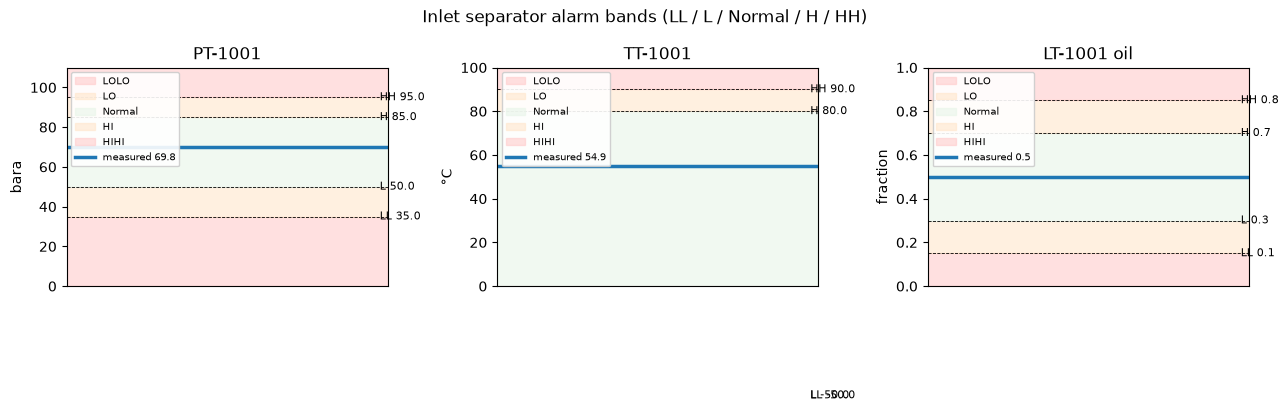

In [4]:
def alarm_bar(ax, title, unit, ll, lo, normal, hi, hh, ymin, ymax):
    ax.axhspan(ymin, ll,  color='#ffcccc', alpha=0.6, label='LOLO')
    ax.axhspan(ll,   lo,  color='#ffe6cc', alpha=0.6, label='LO')
    ax.axhspan(lo,   hi,  color='#e8f5e9', alpha=0.6, label='Normal')
    ax.axhspan(hi,   hh,  color='#ffe6cc', alpha=0.6, label='HI')
    ax.axhspan(hh, ymax,  color='#ffcccc', alpha=0.6, label='HIHI')
    ax.axhline(normal, color='#1f77b4', linewidth=2.5, label=f'measured {normal:.1f}')
    for y, txt in [(ll,'LL'),(lo,'L'),(hi,'H'),(hh,'HH')]:
        ax.axhline(y, color='black', linewidth=0.6, linestyle='--')
        ax.text(0.95, y, f'  {txt} {y:.1f}', va='center', ha='left', fontsize=8)
    ax.set_xlim(0, 1); ax.set_xticks([])
    ax.set_ylim(ymin, ymax)
    ax.set_ylabel(unit); ax.set_title(title)
    ax.legend(loc='upper left', fontsize=7, framealpha=0.9)

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
alarm_bar(axes[0], 'PT-1001', 'bara', 35.0, 50.0, report.getSeparatorPressure(),    85.0, 95.0, 0.0, 110.0)
alarm_bar(axes[1], 'TT-1001', '°C',   -50.0, -50.0, report.getSeparatorTemperature(), 80.0, 90.0, 0.0, 100.0)
alarm_bar(axes[2], 'LT-1001 oil', 'fraction', 0.15, 0.30, 0.50, 0.70, 0.85, 0.0, 1.0)
plt.suptitle('Inlet separator alarm bands (LL / L / Normal / H / HH)')
plt.tight_layout()
plt.show()

## 5. PSV-1001 — API 520 sizing

In [5]:
scenario_results = dict(report.getScenarioResults())
controlling_name = report.getControllingScenario()
controlling_area_mm2 = report.getControllingOrificeArea() * 1.0e6

print(f'Controlling scenario : {controlling_name}')
print(f'Controlling orifice  : {controlling_area_mm2:.2f} mm²\n')
print(f"{'Scenario':25} {'Service':6} {'Set P':>10} {'Orifice':>12} {'Controlling':>12}")
print('-' * 70)
for name, r in scenario_results.items():
    print(f'{str(name):25} {str(r.getFluidService()):6} '
          f'{r.getSetPressureBar():>8.2f} bara '
          f'{r.getRequiredOrificeArea()*1e6:>8.2f} mm² '
          f'{str(r.isControllingScenario()):>12}')

Controlling scenario : Blocked gas outlet
Controlling orifice  : 2686.78 mm²

Scenario                  Service      Set P      Orifice  Controlling
----------------------------------------------------------------------
Blocked gas outlet        GAS      100.00 bara  2686.78 mm²         True
External fire             FIRE     100.00 bara  1242.14 mm²        False


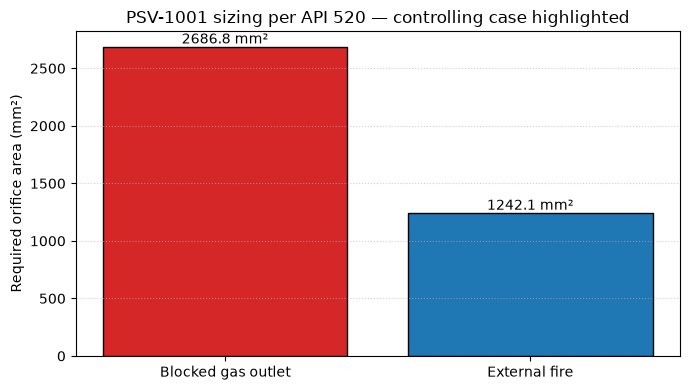

In [6]:
names  = [str(n) for n in scenario_results.keys()]
areas  = [scenario_results[n].getRequiredOrificeArea() * 1.0e6 for n in scenario_results.keys()]
colors = ['#d62728' if str(n) == str(controlling_name) else '#1f77b4' for n in scenario_results.keys()]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(names, areas, color=colors, edgecolor='black')
ax.set_ylabel('Required orifice area (mm²)')
ax.set_title('PSV-1001 sizing per API 520 — controlling case highlighted')
ax.grid(axis='y', linestyle=':', alpha=0.6)
for bar, area in zip(bars, areas):
    ax.text(bar.get_x() + bar.get_width()/2, area, f'{area:.1f} mm²',
            ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## 6. Safety Instrumented System (IEC 61511)

- **SIF-001** Inlet ESD high-pressure trip (PT-1001 HIHI 2oo3 → ESDV-1001) — SIL 2
- **SIF-002** Low-low oil level trip (LT-1001 LOLO 1oo2 → LV-1001) — SIL 1
- **SIF-003** Confirmed fire/gas zonal ESD (2oo3 F&G → ESDV-1001) — SIL 2

In [7]:
sifs = dict(report.getSifs())
print(f"{'SIF':8} {'SIL':>4} {'PFD':>10} {'RRF':>8}  {'Category':14}  Name")
print('-' * 90)
for sif in sifs.values():
    print(f'{str(sif.getId()):8} {int(sif.getSil()):>4} {sif.getPfdAvg():>10.2e} '
          f'{sif.getRiskReductionFactor():>8.0f}  {str(sif.getCategory().getDescription()):14}  {sif.getName()}')

SIF       SIL        PFD      RRF  Category        Name
------------------------------------------------------------------------------------------
SIF-001     2   5.00e-03      200  Emergency Shutdown  Inlet separator high-pressure ESD
SIF-002     1   5.00e-02       20  Process Shutdown  Inlet separator low-low oil level trip
SIF-003     2   3.00e-03      333  Fire & Gas      Confirmed fire/gas zonal ESD


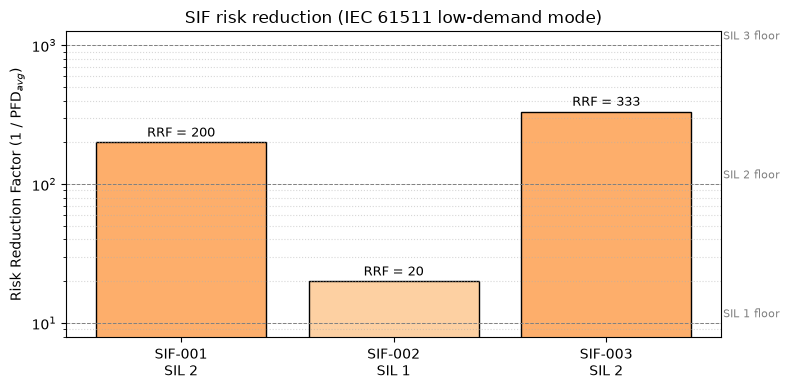

In [8]:
labels = [f'{str(s.getId())}\nSIL {int(s.getSil())}' for s in sifs.values()]
rrfs   = [float(s.getRiskReductionFactor()) for s in sifs.values()]
sil_colors = {1: '#fdd0a2', 2: '#fdae6b', 3: '#e6550d', 4: '#a63603'}
bar_colors = [sil_colors[int(s.getSil())] for s in sifs.values()]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(labels, rrfs, color=bar_colors, edgecolor='black')
for y, name in [(10, 'SIL 1 floor'), (100, 'SIL 2 floor'), (1000, 'SIL 3 floor')]:
    ax.axhline(y, color='grey', linestyle='--', linewidth=0.7)
    ax.text(len(labels) - 0.45, y * 1.1, name, fontsize=8, color='grey')
ax.set_yscale('log')
ax.set_ylabel('Risk Reduction Factor (1 / PFD$_{avg}$)')
ax.set_title('SIF risk reduction (IEC 61511 low-demand mode)')
ax.grid(axis='y', which='both', linestyle=':', alpha=0.5)
for x, r in enumerate(rrfs):
    ax.text(x, r * 1.1, f'RRF = {r:.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 7. LOPA — Inlet separator overpressure scenario

Independent Protection Layers credited:

| IPL | PFD |
|---|---|
| BPCS PC-1001 pressure control | 1.0 × 10⁻¹ |
| PSH alarm + operator response | 1.0 × 10⁻¹ |
| SIF-001 inlet ESD trip (SIL 2) | 5.0 × 10⁻³ |
| PSV-1001 mechanical relief | 1.0 × 10⁻² |

Target frequency derived from STS-0131 overpressure category for an event
pressure equal to MAWP (test pressure = 1.5 × design).

In [10]:
lopa = report.getOverpressureLopa()

initiating = float(lopa.getInitiatingEventFrequency())
target     = float(lopa.getTargetFrequency())
mitigated  = float(lopa.getMitigatedFrequency())

print(f'Scenario          : {lopa.getScenarioName()}')
print(f'Initiating freq   : {initiating:.2e} /yr')
print(f'Target freq       : {target:.2e} /yr  (STS-0131 overpressure)')
print(f'Mitigated freq    : {mitigated:.2e} /yr')
print(f'Total RRF         : {lopa.getTotalRRF():.1f}')
print(f'Target met?       : {bool(lopa.isTargetMet())}')

Scenario          : Inlet separator overpressure (V-100)
Initiating freq   : 1.00e-01 /yr
Target freq       : 1.00e-03 /yr  (STS-0131 overpressure)
Mitigated freq    : 5.00e-08 /yr
Total RRF         : 2000000.0
Target met?       : True


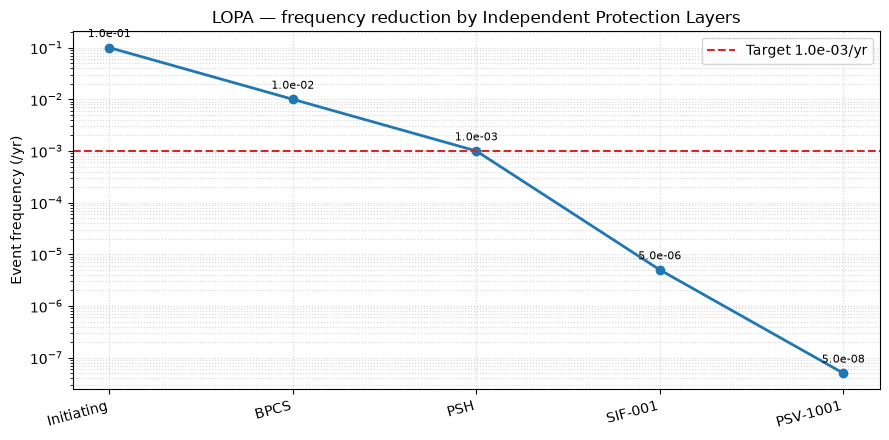

In [11]:
# Rebuild the cumulative frequency progression by reading the layer list back
layers = list(lopa.getLayers())
stage_labels = ['Initiating']
freq_progress = [initiating]
f = initiating
for layer in layers:
    f = f * float(layer.getPfd())
    freq_progress.append(f)
    # Use the first 6 chars of each layer name as a short axis label
    stage_labels.append(str(layer.getName()).split(' ')[0])

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.semilogy(stage_labels, freq_progress, marker='o', linewidth=2, color='#1f77b4')
ax.axhline(target, color='#d62728', linestyle='--',
           label=f'Target {target:.1e}/yr')
for x, y in enumerate(freq_progress):
    ax.text(x, y * 1.6, f'{y:.1e}', ha='center', fontsize=8)
ax.set_ylabel('Event frequency (/yr)')
ax.set_title('LOPA — frequency reduction by Independent Protection Layers')
ax.grid(True, which='both', linestyle=':', alpha=0.5)
ax.legend()
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

## 8. Overpressure trip demonstration

PT-1001 trips its HIHI alarm → SIS executes SIF-001 → ESDV-1001 is
de-energised.

In [12]:
esdv = example.getInletEsdValve()
print(f'ESDV-1001 energised after demonstration : {bool(esdv.isEnergized())}')
print()
print('Trip description (from Java example):')
print('-' * 60)
print(str(report.getTripDescription()))

ESDV-1001 energised after demonstration : False

Trip description (from Java example):
------------------------------------------------------------
PT-1001 HIHI detected (set 100.0 bara). SIF-001 de-energised ESDV-1001 (energized=false). Initiating freq 1.00e-01 /yr -> mitigated 5.00e-04 /yr with RRF 200.


## Summary

- The Python notebook drives [`InletSeparatorSafetySystemExample.java`](../../src/main/java/neqsim/process/examples/InletSeparatorSafetySystemExample.java) via the devtools setup, so the freshly-compiled Java class is loaded from `target/classes` without packaging.
- Steady-state three-phase split is balanced with the 250 t/h feed.
- **PSV-1001** sized per API 520; the controlling scenario and orifice area are reported.
- **SIS** of three SIFs configured per IEC 61511 with explicit SIL / PFD / RRF.
- **LOPA** worksheet shows the credited IPL stack drives mitigated frequency below the STS-0131 target.
- **Trip demonstration** verifies that ESDV-1001 de-energises on SIF-001 activation.

The matching JUnit verification is [`InletSeparatorSafetySystemExampleTest.java`](../../src/test/java/neqsim/process/examples/InletSeparatorSafetySystemExampleTest.java).